## Group Members  
1.  Ifeanyichukwu Imaga Agwu
2.	Victor Chinedu Ezebuiro
3.	Isaac Godspower C.
4.	Nduka, Chukwuemeka J.
5.	Nnokwe Franklin Okechukwu
6.	Anosike Joy Ogechi
7.	Prosper Chukwuemeka Nwankwo
8.	Henry Ajunwa Chibuike
9.	Udi Anita Nzubechukwu
10.	Okafor Enyinnaya Udeh
11.	Chukwuemeka Chimbuchi


## Importing The Required Libraries

In [572]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

**assigning the house variable**

In [573]:
housing = fetch_california_housing(as_frame = True)
df = housing.frame
X = housing.data # the Predictor variable
y = housing.target # the target variable

## Q1. Data Loading, Exploration and Preprocessing  
1(a). Load the dataset

In [574]:
# Display the first five
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [575]:
#  The dimension of the dataset
print(f"The dimension of the dataset is {df.ndim}")

The dimension of the dataset is 2


In [576]:
# The names of all the variables
print(df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


### 1(b) Data Inspection

In [577]:
#  The data Type of each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [578]:
# the number of missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [579]:
# The number of duplicated observation
df.duplicated().sum()

np.int64(0)

In [580]:
# Descriptive statistics for all variables
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [581]:
# Variables containing unusually large or small values
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df < lower) | (df > upper)]
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8.3014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
20635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20636,NaN,NaN,NaN,1.315789,NaN,NaN,NaN,NaN,NaN
20637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


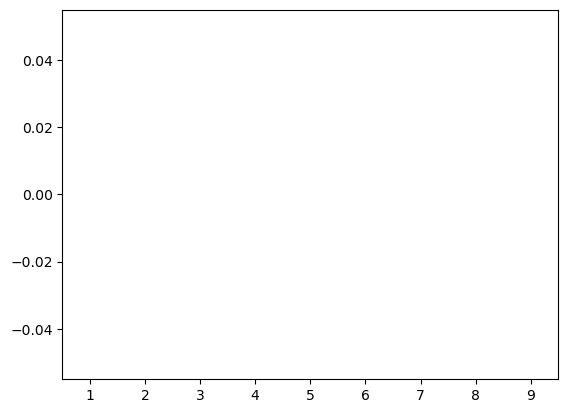

In [582]:
plt.boxplot(outliers)
plt.show()

### 1(c) Exploratory data Analysis

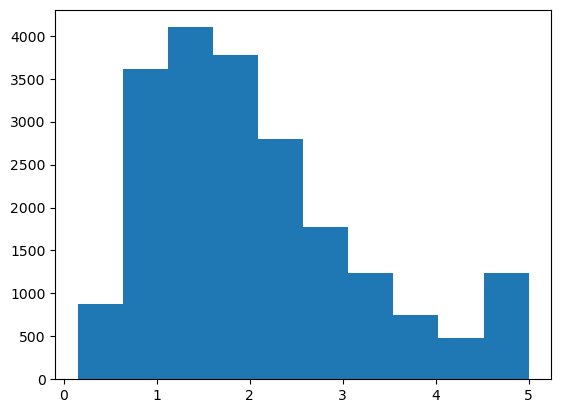

In [583]:
# A histogram of the MedHouseVAl

plt.hist(df["MedHouseVal"])
plt.show()

In [584]:
#  A Correlation Matrix containing all predictors and target variable
corr_matrix = df.corr()
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


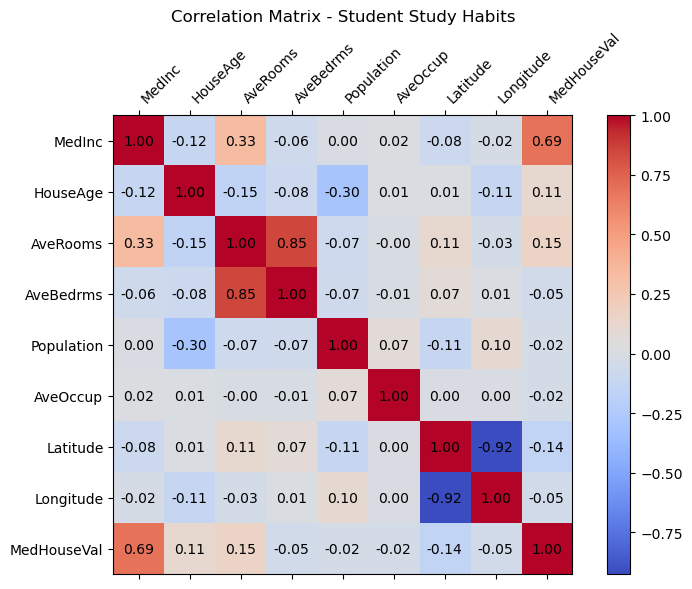

In [585]:
# A heatmap of the correlation matrix
fig, ax = plt.subplots(figsize=(8,6))
cax = ax.matshow(corr_matrix, cmap='coolwarm')  
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='left')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
fig.colorbar(cax)

# add values on cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title("Correlation Matrix - Student Study Habits")
plt.tight_layout()
plt.show()

plt.show()

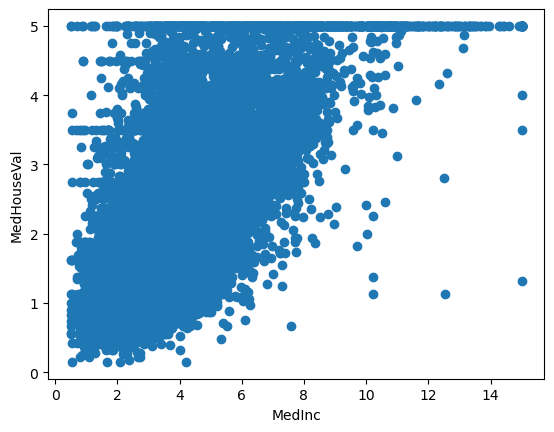

In [586]:
# 4. Scatter plot to show the relationship between selected predicor variable and target variable

plt.scatter(df["MedInc"], y)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.show()


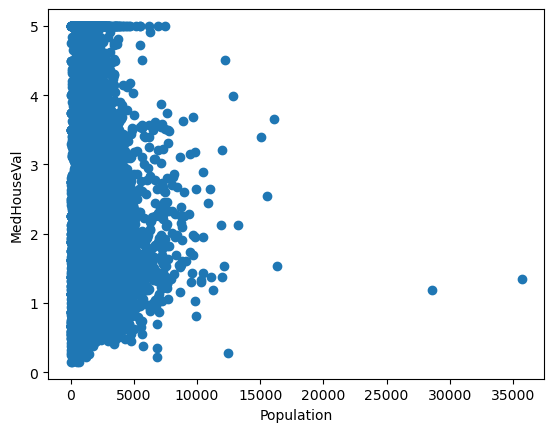

In [587]:
# Scatter plot for Population and MedHouseVal
plt.scatter(df["Population"], y)
plt.xlabel("Population")
plt.ylabel("MedHouseVal")
plt.show()


### `1(d)` Feature Encoding and Scaling

In [588]:
# Scaling the dataset

from sklearn.preprocessing import StandardScaler

In [589]:
# fitting and transforming the Predictor Variables

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns = X.columns, index = X.index)
X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


## `Q2.` Multiple Linear Regression Using a Random Split  
`2(a).` Train - Test split 

In [590]:
#  Splitting the set to training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                   shuffle = True,
                                                   random_state = 42)

In [591]:
# 2b. Model fitting

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [592]:
# 2c. Model Evaluation
# Making prediction on the training set
y_pred_train = model.predict(X_train)

# Making prediction on the testinn set
y_pred_test = model.predict(X_test)

# Training R²
r2_train = r2_score(y_pred_train, y_train)
print(f"The Training R² is {r2_train:.4f}")

# Testing R²
r2_test = r2_score(y_pred_test, y_test)
print(f"\nThe Testing R² is {r2_test:.4f}")

# Train Mean Squared Error 
mse_train = mean_squared_error(y_pred_train, y_train)
print(f"\nThe Training MSE is {mse_train:.4f}")

# Testing Mean Squared Error
mse_test = mean_squared_error(y_pred_test, y_test)
print(f"\nThe Testing MSE is {mse_test:.4f}")

# Train Root Mean Squared Error
rmse_train = np.sqrt(mse_train)
print(f"\nThe Training RMSE is {rmse_train:.4f}")

# Testing Root Mean Squared Error
rmse_test = np.sqrt(mse_test)
print(f"\nThe Testing RMSE is {rmse_test:.4f}")

# Train Mean Absolute Error
mae_train = mean_absolute_error(y_pred_train, y_train)
print(f"\nThe Train MAE is {mae_train:.4f}")

# Testing Mean Absolute Error
mae_test = mean_absolute_error(y_pred_test, y_test)
print(f"\nThe Test MAE is {mae_train:.4f}")

The Training R² is 0.3675

The Testing R² is 0.3377

The Training MSE is 0.5179

The Testing MSE is 0.5559

The Training RMSE is 0.7197

The Testing RMSE is 0.7456

The Train MAE is 0.5286

The Test MAE is 0.5286


### `2(d)`. Interpretation  
The Model tends to be Generalising well because there are no much differences in the error between the training and the testing set


## `Q3.`  Five-Fold Cross-Validation   
`3(a).` Cross-Validation Strategy 

In [593]:
# Importing the required Library
from sklearn.model_selection import KFold

cv = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

#### Why Shuffle and Random State are important  
+ Because it is not a time dependent variable, it is important to shuffle before training the model to ensure it learns the pattern without being biased.
+ The random State is set to a fixed number because the result will keep changing if there is no seed value to make it a fixed output. 

`3(b).` cross-Validation Implementation

In [594]:
# Importing the required Libraries
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

In [595]:
scoring = { 
"mse": "neg_mean_squared_error" 
} 

# Create Linear Regression Pipeline
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


cv_results = cross_validate(
    linear_pipeline,
    X, y,
    scoring = scoring,
    cv = cv,
)

#  Convert the negative MSE to positive
cv_mse = -cv_results["test_mse"]

print("Five-Fold Cross Validation MSE")
print(cv_mse)

Five-Fold Cross Validation MSE
[0.5558916  0.52765625 0.50928321 0.50485078 0.55518048]


`3(d).` Comparison

In [596]:
print(f"Train-Test MSE: {mse_test:.4f}")
print(f"Average Five-Fold MSE: {cv_mse}")

Train-Test MSE: 0.5559
Average Five-Fold MSE: [0.5558916  0.52765625 0.50928321 0.50485078 0.55518048]


*The close similarity between these values indicates that the Linear Regression model performs consistently across different subsets of the data.*

*This suggests that the model generalizes well and that the performance observed from the single train-test split is reliable. Furthermore, five-fold cross-validation provides a more robust estimate of model performance because it evaluates the model on multiple train-test partitions, reducing the impact of any single random split.*

## `Q4:` Ridge Regression Using GridSearchCV

### `4(a).` Build a Ridge Pipeline

In [597]:
# Importing Necessary Library
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

In [601]:
# Create a Pipeline containing StandardScaler and Pipeline
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model_ridge", Ridge())
])

### `4(b).` Hyperparameter Tuning

In [605]:
ridge_grid = {
    "model_ridge__alpha" : [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}


# GridSearrch with five fold validation and Negative MSE
ridge_search = GridSearchCV(
    estimator = ridge_pipeline,
    param_grid = ridge_grid,
    cv = 5,
    scoring = "neg_mean_squared_error"
)



In [606]:
# Fitting the Ridge into the model
ridge_search.fit(X_train, y_train)

print("Best alpha:",ridge_search.best_params_)
print("Best CV Score: ",ridge_search.best_score_)

best_ridge = ridge_search.best_estimator_

Best alpha: {'model_ridge__alpha': 0.0001}
Best CV Score:  -0.5192652011775267


In [607]:
# Making Predictions
y_train_ridge = ridge_search.predict(X_train)
y_test_ridge = ridge_search.predict(X_test)

### `4(c)` Model Evaluation

In [608]:
# Ridge Training R² 
r2_ridge_train = r2_score(y_train, y_train_ridge)

# Ridge Testing R²
r2_ridge_test = r2_score(y_test, y_test_ridge)

# Ridge Train Mean Squared Error
mse_ridge_train = mean_squared_error(y_train, y_train_ridge)

# Ridge Test Mean Squared Error
mse_ridge_test = mean_squared_error(y_test, y_test_ridge)

# Ridge Train Root Mean Squared Error
rmse_ridge_train = np.sqrt(mse_ridge_train)

# Ridge Test Root Mean Squared Error
rmse_ridge_test = np.sqrt(mse_ridge_test)

# Ridge Train  Mean Absolute Error
mae_ridge_train = mean_absolute_error(y_train, y_train_ridge)

# Ridge Test Mean Absolute Error
mae_ridge_test = mean_absolute_error(y_test, y_test_ridge)

print(f"Ridge Train R² is {r2_ridge_train:.4f}")
print(f"Ridge Test R² is {r2_ridge_test:.4f}")
print(f"Ridge Train MSE is {mse_ridge_train:.4f}")
print(f"Ridge Test MSE is {mse_ridge_test:.4f}")
print(f"Ridge Train RMSE is {rmse_ridge_train:.4f}")
print(f"Ridge Test RMSE is {rmse_ridge_test:.4f}")
print(f"Ridge Train MAE {mae_ridge_train:.4f}")
print(f"Ridge Test MAE {mae_ridge_test:.4f}")

Ridge Train R² is 0.6126
Ridge Test R² is 0.5758
Ridge Train MSE is 0.5179
Ridge Test MSE is 0.5559
Ridge Train RMSE is 0.7197
Ridge Test RMSE is 0.7456
Ridge Train MAE 0.5286
Ridge Test MAE 0.5332


#### **Interpretation**  
Ridge regression employs L2 regularization, which penalizes the squared magnitude of the 
regression coefficients. Unlike Lasso regression, Ridge shrinks coefficients towards zero but 
does not eliminate them completely.

## `Q5:` Lasso Regression Using GridSearchCV

`5(a).` Build a Lasso Pipeline

In [609]:
# Importing the required Library
from sklearn.linear_model import Lasso

In [610]:
# Create a Lasso Pipeline containing StandardScaler and Pipeline
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model_lasso", Lasso(max_iter = 10000))
])

`5(b).` Hyperparameter Tuning

In [611]:
# model_lasso = Lasso()

In [612]:
# Creating the grid for Lasso
lasso_grid = {"model_lasso__alpha" : [0.001, 0.01, 0.1, 1, 10]}

In [613]:
# lasso grid search
lasso_search = GridSearchCV(
    estimator = lasso_pipeline,
    param_grid = lasso_grid,
    cv = 5,
    scoring = "neg_mean_squared_error"

)

lasso_search.fit(X_train, y_train)


print(f"The Best Alpha is {lasso_search.best_params_}")
print(f"The Best CV score is {lasso_search.best_score_}")

best_lasso = lasso_search.best_estimator_

The Best Alpha is {'model_lasso__alpha': 0.001}
The Best CV score is -0.5192614509760378


In [614]:
# Making Prediction on Train set
y_train_lasso = lasso_search.predict(X_train)

# Making Prediction on Test set
y_test_lasso = lasso_search.predict(X_test)

`5(c).` Model Evaluation

In [615]:
# Lasso Training R² 
r2_lasso_train = r2_score(y_train, y_train_lasso)

# Lasso Testing R²
r2_lasso_test = r2_score(y_test, y_test_lasso)

# Lasso Train Mean Squared Error
mse_lasso_train = mean_squared_error(y_train, y_train_lasso)

# Lasso Test Mean Squared Error
mse_lasso_test = mean_squared_error(y_test, y_test_lasso)

# Lasso Train Root Mean Squared Error
rmse_lasso_train = np.sqrt(mse_lasso_train)

# Lasso Test Root Mean Squared Error
rmse_lasso_test = np.sqrt(mse_lasso_test)

# Lasso Train  Mean Absolute Error
mae_lasso_train = mean_absolute_error(y_train, y_train_lasso)

# Lasso Test Mean Absolute Error
mae_lasso_test = mean_absolute_error(y_test, y_test_lasso)

print(f"Lasso Train R² is {r2_lasso_train:.4f}")
print(f"Lasso Test R² is {r2_lasso_test:.4f}")
print(f"Lasso Train MSE is {mse_lasso_train:.4f}")
print(f"Lasso Test MSE is {mse_lasso_test:.4f}")
print(f"Lasso Train RMSE is {rmse_lasso_train:.4f}")
print(f"Lasso Test RMSE is {rmse_lasso_test:.4f}")
print(f"Lasso Train MAE {mae_lasso_train:.4f}")
print(f"Lasso Test MAE {mae_lasso_test:.4f}")

Lasso Train R² is 0.6125
Lasso Test R² is 0.5769
Lasso Train MSE is 0.5180
Lasso Test MSE is 0.5545
Lasso Train RMSE is 0.7197
Lasso Test RMSE is 0.7446
Lasso Train MAE 0.5287
Lasso Test MAE 0.5331


`5(d).` Feature Selection

In [616]:
lasso_coef = best_lasso.named_steps['model_lasso'].coef_
zero_coef = np.sum(lasso_coef == 0)

feature_names = X.columns
removed_features = feature_names[lasso_coef == 0]

print(f"Features Removed are:\n{removed_features}")



Features Removed are:
Index([], dtype='object')


**Interpretation**  
Lasso can reduce coefficients to exactly zero. This step allows it to automatically perform feature selection



## `Q6:`  Elastic Net Regression Using GridSearchCV 

`6(a).` Build an Elastic Net Pipeline

In [617]:
# Import the requrried Libraries
from sklearn.linear_model import ElasticNet

In [618]:
# Hypertuni
elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model_elasticnet", ElasticNet(max_iter = 10000))
])


elastic_grid = {
    "model_elasticnet__alpha" : [
        0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10
    ],
    "model_elasticnet__l1_ratio" : [
        0.1, 0.3, 0.5, 0.7, 0.9
    ]
}

elastic_search = GridSearchCV(
    estimator = elastic_pipeline,
    cv = 5,
    scoring = "neg_mean_squared_error",
    param_grid = elastic_grid
)

# fitting the model
elastic_search.fit(X_train, y_train)

print(f"The Best Alpha is {elastic_search.best_params_}")
print(f"The Best CV score is {elastic_search.best_score_}")

best_elastic = elastic_search.best_estimator_

The Best Alpha is {'model_elasticnet__alpha': 0.0001, 'model_elasticnet__l1_ratio': 0.9}
The Best CV score is -0.5192602553975534


In [619]:
elastic_search = GridSearchCV(
    estimator = elastic_pipeline,
    cv = 5,
    scoring = "neg_mean_squared_error",
    param_grid = elastic_grid
)

# fitting the model
elastic_search.fit(X_train, y_train)

print(f"The Best Alpha is {elastic_search.best_params_}")
print(f"The Best CV score is {elastic_search.best_score_}")

best_elastic = elastic_search.best_estimator_

The Best Alpha is {'model_elasticnet__alpha': 0.0001, 'model_elasticnet__l1_ratio': 0.9}
The Best CV score is -0.5192602553975534


`6(c).` Model Evaluation

In [620]:
# Making Prediction on Train set
y_train_elastic = elastic_search.predict(X_train)

# Making Prediction on Test set
y_test_elastic = elastic_search.predict(X_test)

In [621]:
# ElasticNet Training R² 
r2_elastic_train = r2_score(y_train, y_train_elastic)

# ElasticNet Testing R²
r2_elastic_test = r2_score(y_test, y_test_elastic)

# ElasticNet Train Mean Squared Error
mse_elastic_train = mean_squared_error(y_train, y_train_elastic)

# ElasticNet Test Mean Squared Error
mse_elastic_test = mean_squared_error(y_test, y_test_elastic)

# ElasticNet Train Root Mean Squared Error
rmse_elastic_train = np.sqrt(mse_elastic_train)

# ElasticNet Test Root Mean Squared Error
rmse_elastic_test = np.sqrt(mse_elastic_test)

# ElasticNet Train  Mean Absolute Error
mae_elastic_train = mean_absolute_error(y_train, y_train_elastic)

# ElasticNet Test Mean Absolute Error
mae_elastic_test = mean_absolute_error(y_test, y_test_elastic)

print(f"ElasticNet Train R² is {r2_elastic_train:.4f}")
print(f"ElasticNet Test R² is {r2_elastic_test:.4f}")
print(f"ElasticNet Train MSE is {mse_elastic_train:.4f}")
print(f"ElasticNet Test MSE is {mse_elastic_test:.4f}")
print(f"ElasticNet Train RMSE is {rmse_elastic_train:.4f}")
print(f"ElasticNet Test RMSE is {rmse_elastic_test:.4f}")
print(f"ElasticNet Train MAE {mae_elastic_train:.4f}")
print(f"ElasticNet Test MAE {mae_elastic_test:.4f}")

ElasticNet Train R² is 0.6126
ElasticNet Test R² is 0.5759
ElasticNet Train MSE is 0.5179
ElasticNet Test MSE is 0.5558
ElasticNet Train RMSE is 0.7197
ElasticNet Test RMSE is 0.7455
ElasticNet Train MAE 0.5286
ElasticNet Test MAE 0.5332


`6(d).` **Interpretation**  
ElasticNet combines both `L1` and `L2` Regularization and penalties. It shrinks coefficient while also allowing feeature selection.

## `Q7:` Model Performance Comparison

| Model | Optimal Alpha | Optimal L1 Ratio | Test MSE | Test RMSE | Test MAE | Test R² |
|---|---|---|---|---|---|---|
| **Linear Regression** | N/A | N/A | 0.5559 | 0.7197 | 0.5286 | 0.3377|
| **Ridge** |  0.0001 | N/A | 0.5550 | 0.7450 | 0.5332 | 0.5764 |
| **Lasso** |  0.001 | N/A | 0.5545 | 0.7446 | 0.5331 | 0.5769 |
| **ElasticNet** |  0.0001 | 0.9 | 0.5558 | 0.7455 | 0.5332 | 0.5759 |

***Explanation of the table:***

*All three regularized models (Ridge, Lasso, and Elastic Net) selected the same optimal alpha value (0.0001). This indicates that the dataset required very little regularization, which explains why the performance of all four models is nearly identical. The small differences in MSE, RMSE, MAE, and R² suggest that the ordinary Linear Regression model already fits the California Housing dataset quite well, while regularization provides only a marginal improvement.*

1. **Which model has the lowest test MSE?** *Lasso Regression*

2. **Which model has the lowest test RMSE?** *Lasso Regression and Elastic Net Regression*

3. **Which model has the lowest test MAE?** *All four models*

4. **Which model has the highest test 𝑅2?** *Lasso Regression and Elastic Net Regression*

5. **Did regularisation improve predictive performance?** *Yes, but only slightly.

*The regularized models (Ridge, Lasso, and Elastic Net) performed almost the same as Linear Regression. Lasso and Elastic Net showed a very small improvement in test MSE and test R², but the improvement was minimal.*

6. **Are the differences between the models practically important?** *No.

*Although there are small numerical differences between the models, they are very minor. The performance metrics are almost identical, meaning all four models would make very similar predictions on this dataset.*

7. **Which model would you recommend for prediction?** *Lasso Regression.*

8. **Give a reason for your recommendation**

*Lasso Regression is recommended because it achieved the lowest test MSE, shared the lowest RMSE, and achieved the highest test R² among the models evaluated. Although the improvement over the other models is small, Lasso produced the best overall predictive performance.*

*In addition, Lasso has the advantage of being able to perform feature selection by reducing unimportant coefficients to zero when appropriate. While no features were removed in this dataset because the optimal regularization parameter (α = 0.0001) was very small, Lasso still provided the strongest overall performance.*

## `Q8:` Coefficient Shrinkage Comparison 

In [622]:
# fitting the LInear Regression into a pipeline
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


# fitting the Linear Regression into the train set
linear_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [625]:
linear_coef = linear_pipeline.named_steps["model"].coef_
ridge_coef = best_ridge.named_steps["model_ridge"].coef_
lasso_coef = best_lasso.named_steps["model_lasso"].coef_
elastic_coef = best_elastic.named_steps["model_elasticnet"].coef_


In [626]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": linear_coef,
    "Ridge": ridge_coef,
    "Lasso": lasso_coef,
    "Elastic Net": elastic_coef
})


In [628]:
print("\nCoefficient Table")
coef_table



Coefficient Table


,Feature,Linear Regression,Ridge,Lasso,Elastic Net
0,MedInc,0.854383,0.854383,0.849140,0.853904
1,HouseAge,0.122546,0.122546,0.123346,0.122632
2,AveRooms,-0.294410,-0.294410,-0.281273,-0.293199
3,AveBedrms,0.339259,0.339259,0.326050,0.338032
4,Population,-0.002308,-0.002308,-0.001062,-0.002191
5,AveOccup,-0.040829,-0.040829,-0.039890,-0.040745
6,Latitude,-0.896929,-0.896929,-0.885822,-0.895798
7,Longitude,-0.869842,-0.869842,-0.858093,-0.868652


In [632]:
print("\nLargest coefficient magnitude:")
coef_table.max()


Largest coefficient magnitude:


Feature              Population
Linear Regression      0.854383
Ridge                  0.854383
Lasso                   0.84914
Elastic Net            0.853904
dtype: object

**Questions and Answers**

**1. Which model produces the largest coefficient magnitudes?**

*Linear Regression and Ridge Regression produce the largest coefficient magnitudes. In our results, their coefficients are identical for all features.*

**2. Does Ridge shrink most coefficients towards zero?**

*No. In our output, the Ridge coefficients are exactly the same as those of Linear Regression, indicating that Ridge did not noticeably shrink the coefficients. This suggests the optimal regularisation parameter (α) selected during cross-validation is very small, making Ridge behave like ordinary Linear Regression.*

**3. Does Ridge set any coefficients exactly to zero?**

*No. Ridge Regression reduces coefficient magnitudes but does not force coefficients to become exactly zero.*

**4. Which coefficients are set to zero by Lasso?**

*None. All eight features have non-zero coefficients in the Lasso model.*

**5. Which coefficients are set to zero by Elastic Net?**

*None. All eight features retain non-zero coefficients in the Elastic Net model.*

**6. Which model produces the sparsest solution?**

*None of the models. Since neither Lasso nor Elastic Net set any coefficients to zero, all models retained all eight predictors. Therefore, none produced a sparse solution for this dataset.*

**7. Which model is most appropriate for automatic feature selection?**

*Lasso Regression. Lasso is designed to perform automatic feature selection by shrinking less important coefficients exactly to zero. Although it did not eliminate any features in our results, it remains the preferred model for feature selection in general.*

**8. Which model is generally more suitable when predictors are strongly correlated?**

*Ridge Regression. Ridge is generally preferred when predictors are highly correlated because it shrinks coefficients without removing variables, helping to reduce multicollinearity while retaining all predictors.*

In [642]:
print("\nRidge zero coefficients:",
      np.sum(ridge_coef == 0))


Ridge zero coefficients: 0


In [634]:
print("Lasso zero coefficients:",
      np.sum(lasso_coef == 0))

Lasso zero coefficients: 0


In [635]:
print("Elastic Net zero coefficients:",
      np.sum(elastic_coef == 0))

Elastic Net zero coefficients: 0


In [636]:
print("\nFeatures removed by Lasso")
print(list(X.columns[lasso_coef == 0]))


Features removed by Lasso
[]


In [637]:
print("\nFeatures removed by Elastic Net")
print(list(X.columns[elastic_coef == 0]))


Features removed by Elastic Net
[]


## `Q9:` Grouped Bar Chart

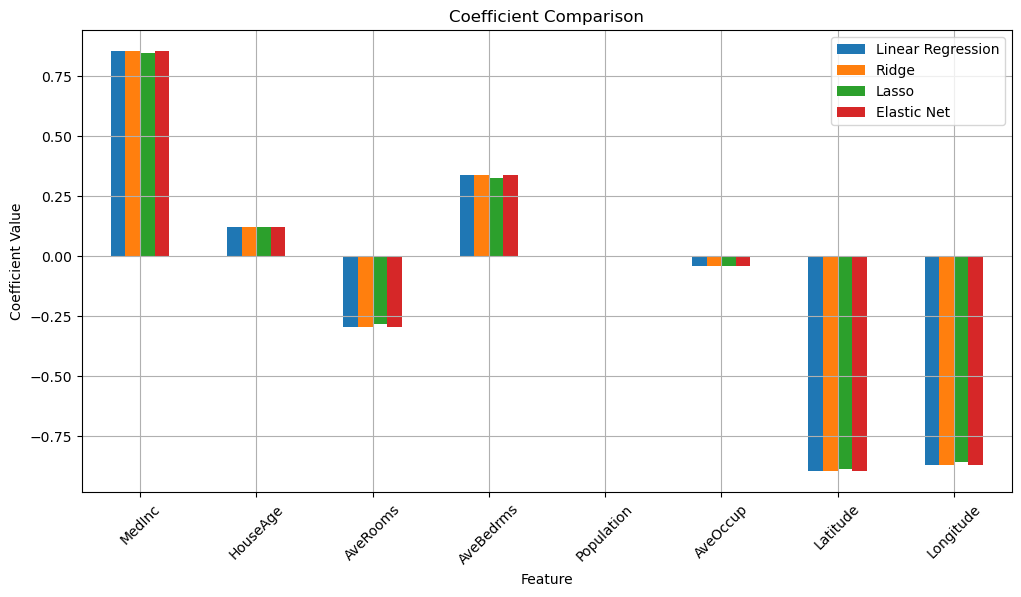

In [638]:
coef_table.set_index("Feature").plot(
    kind="bar",
    figsize=(12,6)
)	

plt.title("Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### FINAL INTERPRETATION  
`1.` Ridge shrinks coefficients but keeps all variables.  
`2.` Lasso performs automatic feature selection.  
`3.` Elastic Net combines Ridge and Lasso penalties.  
`4.` Choose the model with the lowest Test MSE and highest Test R².  


**Conclusion**:

The coefficient comparison shows that all four regression models produced similar coefficients, with Lasso and Elastic Net applying only slight shrinkage. No coefficients were reduced to zero, indicating that all eight predictors were useful and no feature selection occurred.

Model evaluation also showed nearly identical predictive performance across all models. Therefore, regularisation had little practical impact on this dataset.

Ridge Regression is our final recommended because it retains strong predictive performance while providing greater robustness to multicollinearity and overfitting.

## `Q10:` SDG Regression

In [643]:
from sklearn.linear_model import SGDRegressor

sgd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDRegressor(
        random_state=42,
        max_iter=1000,
        tol=1e-3
    ))
])

# Training the model
sgd_pipeline.fit(X_train, y_train)


# Make predictions
sgd_pred = sgd_pipeline.predict(X_test)


# Compute the Evaluation Metrics
sgd_mse = mean_squared_error(y_test, sgd_pred)
sgd_rmse = np.sqrt(sgd_mse)
sgd_mae = mean_absolute_error(y_test, sgd_pred)


In [644]:
print(f"SGD MAE : {sgd_mae:.4f}")
print(f"SGD MSE : {sgd_mse:.4f}")
print(f"SGD RMSE: {sgd_rmse:.4f}")

SGD MAE : 0.5299
SGD MSE : 0.5506
SGD RMSE: 0.7420


**Interpretation:** SGDRegressor is an optimization algorithm rather than a different regression formula.

From the results obtained from training the model using SGD Regression, the following interpreations hold:

*Mean Absolute Error (MAE = 0.5299):*
On average, the model's predictions differ from the actual house prices by approximately 0.53 units.

*Mean Squared Error (MSE = 0.5506):*
The average squared prediction error is 0.5506, indicating the model fits the data reasonably well.

*Root Mean Squared Error (RMSE = 0.7420):*
The model's prediction error is approximately 0.74 units on the original target scale.

**Comparison with Previous Models**
From our earlier results:


| Model              |        MAE |        MSE |       RMSE |
| ------------------ | ---------: | ---------: | ---------: |
| Linear Regression  |     ≈0.533 |     ≈0.555 |     ≈0.745 |
| Ridge              |     ≈0.533 |     ≈0.555 |     ≈0.745 |
| Lasso              |     ≈0.533 |     ≈0.555 |     ≈0.745 |
| Elastic Net        |     ≈0.533 |     ≈0.555 |     ≈0.745 |
| **SGD Regression** | **0.5299** | **0.5506** | **0.7420** |


Interestingly, SGD Regression achieved slightly lower MAE, MSE, and RMSE than the previous regression models. The improvement is small, so while SGD performed marginally better on this test set, the difference is not large enough to suggest a substantial practical advantage.
